In [6]:
# Importa as bibliotecas necessárias

import math
import re
import matplotlib.pyplot as plt

1) Implementação dos métodos para ler o dataset, gerar gráfico de dispersão, calcular a regressão e a correlação.

In [7]:
def le_dados(caminho_arquivo: str) -> dict[str, list[float]]:
    """
    le o arquivo txt e retorna o dicionario com os vetores
    """
    datasets = {}
    with open(caminho_arquivo, 'r') as f:
        conteudo = f.read()

    padrao = r'(\w+)\s*=\s*\[([^\]]+)\]'
    for dado in re.finditer(padrao, conteudo):
        nome = dado.group(1)
        valores = [float(v.strip()) for v in dado.group(2).split(';') if v.strip()]
        datasets[nome] = valores

    return datasets


def gera_grafico_dispersao(x: list[float], y: list[float], label_x: str, label_y: str, titulo: str = 'Diagrama de dispersao'):
    """
    gera o diagrama de dispersao para os vetores x e y fornecidos
    """
    plt.scatter(x, y)
    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.title(titulo)
    plt.grid(True)
    plt.autoscale()


def correlacao(vetor1: list[float], vetor2: list[float]) -> float:
    """
    Funcao responsavel por realizar o calculo do
    coeficiente de correlacao entre os dados
    """
    n = len(vetor1)
    media_x = sum(vetor1) / n
    media_y = sum(vetor2) / n

    numerador = sum((vetor1[i] - media_x) * (vetor2[i] - media_y) for i in range(n))
    denominador = math.sqrt(
        sum((vetor1[i] - media_x) ** 2 for i in range(n)) *
        sum((vetor2[i] - media_y) ** 2 for i in range(n))
    )

    return numerador / denominador


def regressao(vetor1: list[float], vetor2: list[float]):
    """
    Calcula os coef beta0 e beta1 da reta de regressao linear
    """
    n = len(vetor1)
    media_x = sum(vetor1) / n
    media_y = sum(vetor2) / n

    beta1 = (
        sum((vetor1[i] - media_x) * (vetor2[i] - media_y) for i in range(n)) /
        sum((vetor1[i] - media_x) ** 2 for i in range(n))
    )
    beta0 = media_y - beta1 * media_x

    return beta0, beta1

2) Execução dos seguintes comandos:

   

*   Gráfico de Dispersão.
*   Cálculo do coeficiente e correlação
*   Traçar linha de regressão no Gráfico de dispersão
*   Mostrar os coeficientes de correlação e regressão no Gráfico de Dispersão



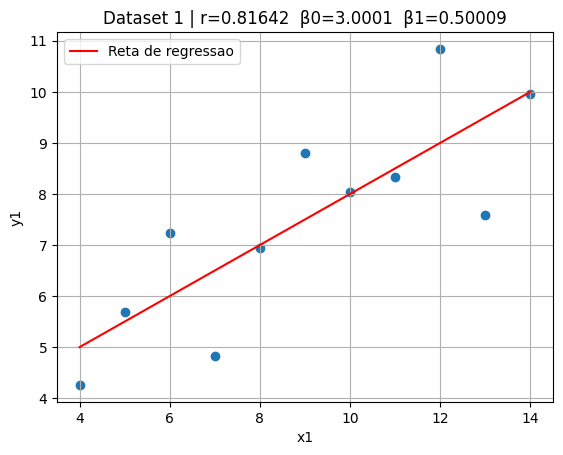

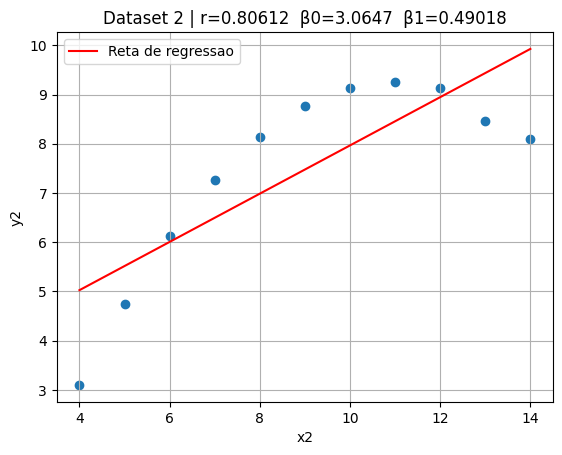

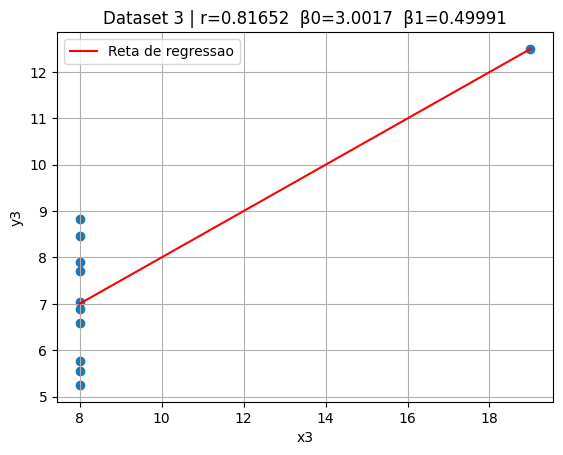

In [8]:
def demo():
  dados = le_dados('dados.txt')

  grupos = [
      ('x1', 'y1', 'Dataset 1'),
      ('x2', 'y2', 'Dataset 2'),
      ('x3', 'y3', 'Dataset 3'),
  ]

  for nome_x, nome_y, dataset in grupos:
      x = dados[nome_x]
      y = dados[nome_y]

      r = correlacao(x, y)
      beta0, beta1 = regressao(x, y)

      gera_grafico_dispersao(x, y, label_x=nome_x, label_y=nome_y)

      x_linha = [min(x), max(x)]
      y_linha = [beta0 + beta1 * xi for xi in x_linha]
      plt.plot(x_linha, y_linha, color='red', label='Reta de regressao')

      plt.title(f'{dataset} | r={r:.5f}  β0={beta0:.4f}  β1={beta1:.5f}')
      plt.legend()
      plt.show()


demo()

3)  Qual dos datasets não é apropriado para regressão linear?

   O dataset 2 não apresenta um bom ajuste utilizando regressão linear, pois ocorre underfitting.
  Isso significa que o modelo linear é simples demais para capturar o padrão dos dados, que possuem um comportamento não linear.
  Para esse tipo de situação, o mais adequado seria utilizar um modelo mais complexo, como a regressão polinomial,
  que consegue representar melhor curvas e variações mais complexas.

  O dataset 3 não é apropriado para regressão linear, nem para outros modelos preditivos, pois apresenta uma relação inconsistente entre as variáveis.
  Apesar de poder existir alguma correlação, os dados não possuem uma relação causal significativa, caracterizando um caso clássico de “correlação não implica causalidade”.
  Além disso, a distribuição dos pontos é inadequada para modelagem, o que compromete qualquer tentativa de ajuste confiável.